# Reconhecimento de Atividades Humanas (HAR)
### Processamento Digital de Sinais e Machine Learning

## Objetivo

O Reconhecimento de Atividades Humanas (do inglês, Human Activity Recognition - HAR) é uma área de estudo focada na identificação sistemática de ações físicas realizadas por indivíduos, utilizando dados coletados por instrumentos de medição. No contexto deste projeto, os dados provêm de um sensor acelerômetro, que registrou a aceleração triaxial (eixos X, Y e Z) ao longo do tempo, operando a uma taxa de amostragem aproximada de 98.93hz de uma pessoa real.

O projeto busca classificar três atividades: **caminhada, corrida** e **salto**.

O sinal de um acelerômetro é composto pela combinação linear da aceleração dinâmica do corpo, da força gravitacional estática (que atua em baixas frequências) e de ruídos inerentes ao sensor ou vibrações (em geral, frequências altas). Para contornar essa limitação e tornar os dados interpretáveis para modelos de aprendizado de máquina, aplica-se o Processamento Digital de Sinais (PDS). O projeto parte do sinal bruto e passa por filtragem, janelamento e extração de características antes da classificação. O objetivo é transformar a série temporal em um conjunto de atributos capaz de separar os padrões de movimento e, em seguida, comparar SVM, Random Forest e XGBoost usando validação cruzada e F1 Macro.

## Setup

O projeto usa NumPy e pandas para manipulação dos dados, SciPy para processamento de sinais, Matplotlib e Seaborn para visualização e scikit-learn/XGBoost para classificação e validação.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import entropy
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

## Dataset

O dataset contém 4.305 amostras sequenciais do acelerômetro, distribuídas entre caminhada (2.276), corrida (1.484) e salto (545). Cada amostra registra o tempo, os três eixos de aceleração e o comportamento associado.

In [2]:
df = pd.read_csv('../dataset/05_rotulado.csv')
dist = df['comportamento'].value_counts()
print(dist)
print(f"Total de amostras: {df.shape[0]}")



comportamento
caminhada    2276
corrida      1484
salto         545
Name: count, dtype: int64
Total de amostras: 4305


In [3]:
display(df.head())

,time_s,accX_counts,accY_counts,accZ_counts,comportamento
0,0.001171,-15384,860,3956,caminhada
1,0.011568,-15204,852,3876,caminhada
2,0.021852,-15400,852,3644,caminhada
3,0.032104,-15280,832,3704,caminhada
4,0.042358,-15452,744,3544,caminhada


In [4]:
display(df.tail())

,time_s,accX_counts,accY_counts,accZ_counts,comportamento
4300,43.464419,-10976,-1096,4008,salto
4301,43.474511,-6656,-28,5208,salto
4302,43.484637,-5448,-228,4712,salto
4303,43.494730,-3288,824,5680,salto
4304,43.504822,-2644,788,6044,salto


## Taxa de amostragem

A taxa de amostragem é calculada diretamente a partir do vetor de tempo.

Primeiro calcula-se o intervalo médio entre amostras consecutivas ($\Delta t$). A frequência de amostragem é então obtida por:

$$f_s = \frac{1}{\Delta t}$$

O desvio padrão de $\Delta t$ também é observado para verificar a estabilidade temporal da extração. No dataset, a taxa calculada é de aproximadamente **98,93 Hz**.

In [5]:
def calcular_taxa_amostragem(df, col_temp='time_s'):

  dif_temp = df[col_temp].diff()
  dif_temp = dif_temp.dropna()
  delt_t_med = dif_temp.mean()
  delt_t_desvio = dif_temp.std()
  taxa_freq_media = 1 / delt_t_med

  print(f"intervalo de tempo medio: {delt_t_med:.6f} segundos")
  print(f"desvio padrão {delt_t_desvio:.6f} segundos")
  print(f"taxa de amostragem calculada {taxa_freq_media:.2f} hz")
  return taxa_freq_media
fs = calcular_taxa_amostragem(df)

intervalo de tempo medio: 0.010108 segundos
desvio padrão 0.000050 segundos
taxa de amostragem calculada 98.93 hz


## Pré-processamento dos sinais

### Projeto dos filtros

Como dito anteriormente, o sinal do acelerômetro combina movimento, componente gravitacional e ruído. A filtragem busca manter a faixa associada ao movimento humano e reduzir componentes que não ajudam na classificação.

- **Filtro Passa-baixa Butterworth, $f_c = 20$ Hz:** reduz componentes de alta frequência.
- **Filtro Passa-alta Butterworth, $f_c = 0{,}3$ Hz:** reduz a componente de baixa frequência associada à gravidade.

Foi adotado um filtro Butterworth de ordem 3 pela resposta suave na banda de passagem. 

#### Filtro Butterworth base

Uma função gera os coeficientes do filtro de ordem 3. O tipo do filtro e a frequência de corte são definidos na chamada do método, permise permitindo usar a mesma implementação para passa-baixa e passa-alta.

In [6]:
def filtro_passa_baixa_alta (fc, fs, btype, order=3):
  nyq = 0.5 * fs
  normal_fc = fc/nyq
  b, a = signal.butter(order, normal_fc, btype=btype, analog=False)
  return b, a

#### Resposta em frequência e polos e zeros

A resposta em frequência mostra quais faixas são atenuadas pelo filtro. O diagrama de polos e zeros é usado para verificar sua estabilidade no plano Z.

In [ ]:
def plot_caract_filtro (b, a, fs, titulo, f_limite):

  w, h = signal.freqz(b, a, worN=8000, fs=fs)
  z, p, k = signal.tf2zpk(b, a)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
  fig.suptitle(f'Análise do filtro: {titulo}', fontsize=14)

  ax1.plot(w, np.abs(h), color='blue', linewidth=2)
  ax1.axhline(1/np.sqrt(2), color='green', linestyle='--', label='Corte -3dB')
  ax1.set_title('Magnitude da Resposta')
  ax1.set_xlabel('Frequência (Hz)')
  ax1.set_ylabel('Ganho')
  ax1.set_xlim(0, f_limite)
  ax1.grid(True, linestyle=':', alpha=0.7)
  ax1.legend()

  circulo = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
  ax2.add_patch(circulo)
  ax2.scatter(np.real(z), np.imag(z), s=60, marker='o', facecolors='none', edgecolors='blue', label='Zeros')
  ax2.scatter(np.real(p), np.imag(p), s=60, marker='x', color='red', label='Polos')
  ax2.set_title('Plano Z')
  ax2.set_xlabel('Real')
  ax2.set_ylabel('Imaginário')
  ax2.axis('equal')
  ax2.grid(True, linestyle=':', alpha=0.7)
  ax2.legend(loc='upper right')

  plt.tight_layout()
  plt.show()

### Filtro passa-baixa

O passa-baixa usa frequência de corte de **20 Hz**. A resposta em frequência permite verificar a atenuação acima desse ponto, o plano Z permite conferir se os polos permanecem dentro do círculo unitário (ou seja, são matemáticamente estáveis).

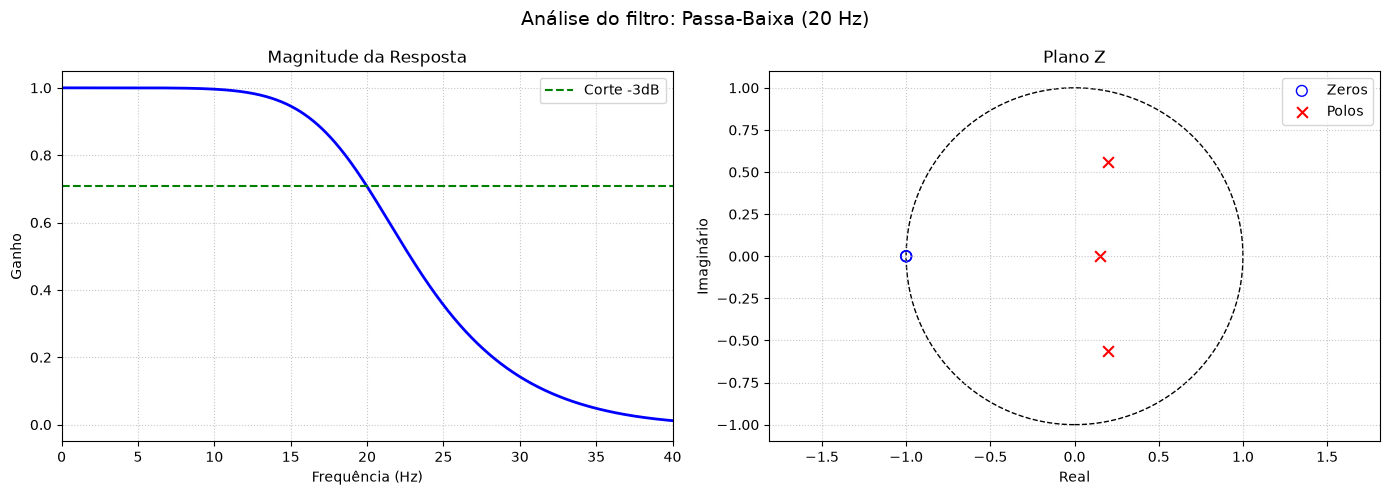

In [8]:
ordem_filtro = 3
fc_baixa = 20.0
b_lp, a_lp = filtro_passa_baixa_alta(fc_baixa, fs, 'low', ordem_filtro)

plot_caract_filtro(b_lp, a_lp, fs, 'Passa-Baixa (20 Hz)', f_limite=40)

Nesta etapa é provado que:

* **Resposta em frequência:** O filtro barra frequências após 20 hz.

* **Polos e zeros:** O filtro projetado é matematicamente estável. 

### Filtro passa-alta

O passa-alta usa frequência de corte de **0,3 Hz** para reduzir a componente quase constante associada à gravidade. Assim como no passa-baixa, a resposta em frequência e o plano Z são usados para verificar a estabilidade e comportamento do filtro.

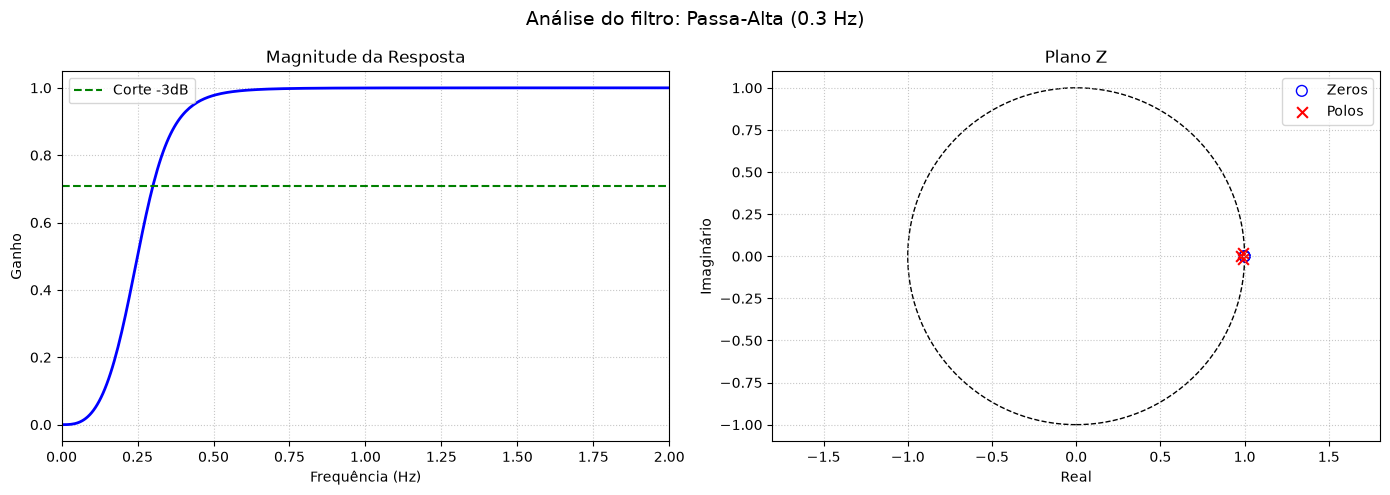

In [9]:
fc_alta = 0.3
b_hp, a_hp = filtro_passa_baixa_alta(fc_alta, fs, 'high', ordem_filtro)
plot_caract_filtro(b_hp, a_hp, fs, 'Passa-Alta (0.3 Hz)', f_limite=2)

Nessa etapa foi provado que:

* **Resposta em frequência:** O filtro barra frequências abaixo de 0.3 hz.

* **Polos e zeros:** O filtro projetado é matematicamente estável.

### Aplicação dos filtros

Os dois filtros são aplicados em sequência aos eixos X, Y e Z. Sendo processado cada sinal nos dois sentidos, visando evitar o atraso de fase que deslocaria temporalmente os picos de movimento.

In [10]:
df_filtrado = df.copy()
eixos = ['accX_counts', 'accY_counts', 'accZ_counts']
for eixo in eixos:
  sinal_bruto = df[eixo].values


  sinal_filtrado = signal.filtfilt(b_hp, a_hp, sinal_bruto)


  sinal_acela_corpo = signal.filtfilt(b_lp, a_lp, sinal_filtrado)

  nome_col_nova = eixo.replace('counts', 'filt')
  df_filtrado[nome_col_nova] = sinal_acela_corpo


### Validação da filtragem

A comparação entre sinal bruto e filtrado é feita no domínio do tempo e da frequência. A FFT (transformada rápida de furrier) permite observar se as componentes fora da faixa escolhida foram reduzidas sem perder o padrão principal do movimento.

In [11]:
display(df_filtrado.head())

,time_s,accX_counts,accY_counts,accZ_counts,comportamento,accX_filt,accY_filt,accZ_filt
0,0.001171,-15384,860,3956,caminhada,44.179034,-100.836127,88.883195
1,0.011568,-15204,852,3876,caminhada,118.780218,-96.274248,-32.245428
2,0.021852,-15400,852,3644,caminhada,135.249132,-111.871910,-133.965503
3,0.032104,-15280,832,3704,caminhada,81.290442,-149.886165,-217.782847
4,0.042358,-15452,744,3544,caminhada,-11.969606,-188.382583,-298.237491


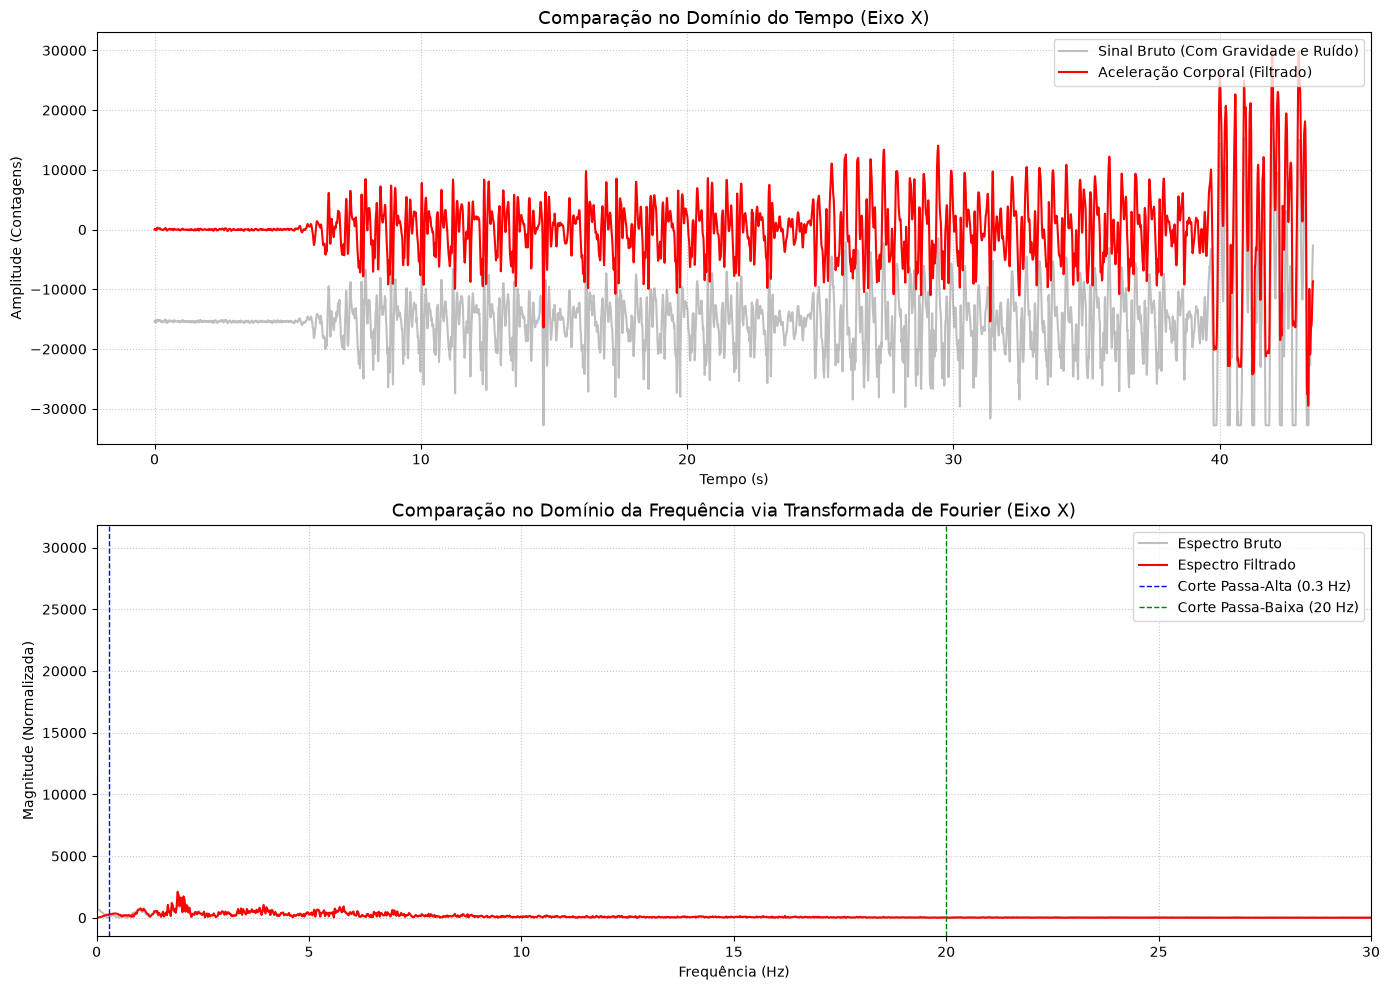

In [ ]:
def computar_espectro_fft (sinal, taxa_amostragem):

  n_amostras = len(sinal)
  frequencias = np.fft.rfftfreq(n_amostras, d=1/taxa_amostragem)



  magnitudes = np.abs(np.fft.rfft(sinal)) * (2.0/n_amostras)

  return frequencias, magnitudes



eixo_teste_bruto = 'accX_counts'
eixo_teste_filtrado = 'accX_filt'

temp = df_filtrado['time_s'].values
x_bruto = df_filtrado[eixo_teste_bruto].values
x_filtrado = df_filtrado[eixo_teste_filtrado].values


freq_orig, mag_orig = computar_espectro_fft(x_bruto, fs)
freq_proc, mag_proc = computar_espectro_fft(x_filtrado, fs)

fig, axs = plt.subplots(2, 1, figsize=(14, 10))


axs[0].plot(temp, x_bruto, label='Sinal Bruto (Com Gravidade e Ruído)', color='gray', alpha=0.5)
axs[0].plot(temp, x_filtrado, label='Aceleração Corporal (Filtrado)', color='red', linewidth=1.5)
axs[0].set_title('Comparação no Domínio do Tempo (Eixo X)', fontsize=13)
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Amplitude (Contagens)')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle=':', alpha=0.7)


axs[1].plot(freq_orig, mag_orig, label='Espectro Bruto', color='gray', alpha=0.5)
axs[1].plot(freq_proc, mag_proc, label='Espectro Filtrado', color='red', linewidth=1.5)
axs[1].axvline(0.3, color='blue', linestyle='--', linewidth=1, label='Corte Passa-Alta (0.3 Hz)')
axs[1].axvline(20.0, color='green', linestyle='--', linewidth=1, label='Corte Passa-Baixa (20 Hz)')
axs[1].set_title('Comparação no Domínio da Frequência via Transformada de Fourier (Eixo X)', fontsize=13)
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (Normalizada)')
axs[1].set_xlim(0, 30)
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


Os filtros funcionaram de forma eficiente para deixar delimitado as frequências, sendo removidas as frequências muito baixas e altas. O que significa termos um campo onde, a princípio, será uma frequência feita por um movimento humano

## Janelamento

Na classificação, o sinal é dividido em janelas para que cada observação represente um trecho completo do movimento.

A escolha do tamanho considerou a duração observada (empírica, olhando o vídeo feito) dos ciclos:

- **Caminhada:** ciclo de dois passos entre 1,15 e 1,18 s.
- **Corrida:** ciclo de dois passos em aproximadamente 0,67 s.
- **Salto:** duração média de aproximadamente 0,38 s por evento.

Foi adotada uma janela de **128 amostras**, aproximadamente **1,28 s**. Esse tamanho cobre o ciclo mais longo observado e mantém uma potência de 2, conveniente para a FFT.

O avanço entre janelas é de **32 amostras**, equivalente a **75% de sobreposição**. O overlap reduz a chance de um movimento ficar dividido apenas na borda de duas janelas e aumenta o número de instâncias disponíveis da classe salto, que é a classe minoritária.

O número de janelas é dado por:

$$N_{janelas} = \left\lfloor \frac{N_{total} - N_w}{passo} \right\rfloor + 1$$

Sendo que:

**$N_{janelas}$**: número de janelas

**$N_{total}:$** Comprimento total do sinal (total de amostras)

 **$N_{w}$:** Tamanho da janela

**$passo:$** Deslocamento a cada passo. É o tamanho da janela subtraído da sobreposição (número de amostras)

### Implementação

O janelamento é aplicado apenas aos três eixos já filtrados e separadamente em cada trecho contínuo de uma mesma atividade. Assim, nenhuma janela atravessa a transição entre dois rótulos e cada janela mantém o rótulo do trecho correspondente.

In [ ]:
def segmentar_sinais(dados_features, dados_rotulos, tam_janela, passo):

  janelas = []
  rotulos = []
  inicios = []
  fins = []

  mudancas = np.where(dados_rotulos[1:] != dados_rotulos[:-1])[0] + 1
  limites = np.concatenate(([0], mudancas, [len(dados_rotulos)]))

  for inicio_bloco, fim_bloco in zip(limites[:-1], limites[1:]):
    rotulo_bloco = dados_rotulos[inicio_bloco]

    for i in range(inicio_bloco, fim_bloco - tam_janela + 1, passo):
      janela_atual = dados_features[i:i+tam_janela]

      janelas.append(janela_atual)
      rotulos.append(rotulo_bloco)
      inicios.append(i)
      fins.append(i + tam_janela - 1)

  return (
      np.array(janelas),
      np.array(rotulos),
      np.array(inicios),
      np.array(fins)
  )


TAM_JANELA = 128
PASSO = 32

col_corpo = ['accX_filt', 'accY_filt', 'accZ_filt']
matriz_sinais = df_filtrado[col_corpo].values
vetor_comportamento = df_filtrado['comportamento'].values


X_janelas, y_janelas, inicios_janelas, fins_janelas = segmentar_sinais(
    matriz_sinais,
    vetor_comportamento,
    TAM_JANELA,
    PASSO
)

print(f"Total de janelas: {X_janelas.shape}")
print(f"Total de rótulos: {y_janelas.shape}")


classes, contagens = np.unique(y_janelas, return_counts=True)

for x, freq in zip(classes, contagens):
  percentual = (freq / len(y_janelas)) * 100
  print(f"{x}: {freq} ({percentual:.2f}%)")

Total de janelas: (125, 128, 3)
Total de rótulos: (125,)
caminhada: 68 (54.40%)
corrida: 43 (34.40%)
salto: 14 (11.20%)


O desbalanceamento entre as classes reforça a utilização da F1 Macro como métrica principal na validação cruzada.

## Extração de características

Cada janela de 128 amostras por 3 eixos é transformada em atributos numéricos. Para cada eixo são extraídas cinco características:

- **Média:** Computa a tendência central do sinal na janela. Como o filtro passa-alta (0.3 Hz) aplicado anteriormente removeu a gravidade (DC), espera-se que a média da aceleração dinâmica tenda a zero.
- **Desvio padrão:** mede a dispersão do sinal e ajuda a representar a intensidade do movimento. Uma janela deslizante contendo a transição de um "salto" apresentará um desvio padrão muito maior do que uma janela de "caminhada", por exemplo.
- **Pico de Fourier:** usa a FFT para capturar a componente de frequência dominante, útil para diferenciar cadências, sendo possível diferenciar os espectros de passos rápidos (corrida) e passos lentos (caminhada).
- **Autocorrelação:** mede a repetição do sinal ao longo do tempo e ajuda a representar movimentos periódicos. Em geral, movimentos de caminhada/corrida geram padrões de autocorrelação com picos bem definidos, muito diferentes de salto, onde naturalmente é mais explosivo e isolado.
- **Entropia espectral:** quantifica o grau de incerteza/desordem do sinal baseando-se em sua Densidade Espectral de Potência (DEP). Uma caminhada em linha reta em ritmo constante (ou pouco variável) gera um sinal de baixa entropia (maior organização). Em contraste, as fases de impacto e transição de uma corrida e salto espalham a energia e geram maior desorganização, resultando em alta entropia.

Como são cinco características para cada um dos três eixos, cada janela é representada por **15 features**.

### Implementação

A função de extração percorre os eixos X, Y e Z de uma janela e calcula as cinco características de cada um. Assim, a matriz original de 128 × 3 é convertida em um vetor de 15 valores.

In [ ]:
def calcular_entropia_espectral (sinal):

  dep = np.abs(np.fft.rfft(sinal))**2


  soma_dep = np.sum(dep)
  if soma_dep == 0:
    return 0.0


  dep_norm = dep/soma_dep


  return entropy(dep_norm, base=2)

def extrair_features_janela (janela):
  features_vetor = []

  for eixo in range(3):
    sinal_eixo = janela[:, eixo]


    media = np.mean(sinal_eixo)


    desvio_padrao = np.std(sinal_eixo)


    fourier = np.abs(np.fft.rfft(sinal_eixo))
    fourier_mag = np.max(fourier[1:]) if len(fourier) > 1 else 0.0


    autocorr = np.correlate(sinal_eixo, sinal_eixo, mode='full')
    autocorr_positiva = autocorr[len(autocorr) // 2:]
    autocorr_media = np.mean(autocorr_positiva)


    entropia_espectral = calcular_entropia_espectral(sinal_eixo)

    features_vetor.extend([media, desvio_padrao, fourier_mag, autocorr_media, entropia_espectral])

  return features_vetor


### Matriz X e vetor y

A extração é aplicada a todas as janelas. Os vetores resultantes formam a matriz **X**, em que cada linha representa uma janela e cada coluna uma característica. O vetor **y** mantém o rótulo de atividade associado a cada janela.

In [15]:

matriz_features = []


for janela in X_janelas:
  features_janela = extrair_features_janela(janela)
  matriz_features.append(features_janela)


X_dados = np.array(matriz_features)
y_rotulos = y_janelas

print(f"Tamanho da matriz de dados (X): {X_dados.shape}")
print(f"Tamanho do vetor de rotulos (y): {y_rotulos.shape}")



nomes_colunas = [
    f"{metrica}_{eixo}" for eixo in ['accX_filt', 'accY_filt', 'accZ_filt']
    for metrica in ['Media', 'Desvio_Padrao', 'FFT_Pico', 'Autocorr', 'Entropia']
]

df_features = pd.DataFrame(X_dados, columns=nomes_colunas)
df_features['comportamento'] = y_rotulos



display(df_features.head())

Tamanho da matriz de dados (X): (125, 15)
Tamanho do vetor de rotulos (y): (125,)


,Media_accX_filt,Desvio_Padrao_accX_filt,FFT_Pico_accX_filt,Autocorr_accX_filt,Entropia_accX_filt,Media_accY_filt,Desvio_Padrao_accY_filt,FFT_Pico_accY_filt,Autocorr_accY_filt,Entropia_accY_filt,Media_accZ_filt,Desvio_Padrao_accZ_filt,FFT_Pico_accZ_filt,Autocorr_accZ_filt,Entropia_accZ_filt,comportamento
0,29.723445,100.419833,3349.590098,62026.735613,4.021557,-40.357280,114.949177,5442.748897,111658.453733,3.200290,-76.003964,205.823918,15732.873547,393772.610105,2.283488,caminhada
1,0.382255,84.165746,3129.474885,3551.361012,4.218564,19.930396,80.518764,3490.231687,28862.371147,3.775182,-69.012876,209.308635,13911.195740,329104.170529,2.874449,caminhada
2,-7.578755,73.418730,2327.214210,6399.875729,4.150602,33.374633,68.197371,2687.275388,74169.804397,3.608284,-15.782419,221.034832,11785.077352,40494.165405,2.913936,caminhada
3,-9.490119,73.023258,2661.279416,8475.219962,4.280910,28.870173,69.914674,3168.493217,56203.934258,3.658865,2.478230,224.116545,11927.445981,25510.247765,2.901244,caminhada
4,-0.412005,84.232717,2845.066085,3558.524081,4.122324,-41.929894,137.185252,7002.393124,122808.381492,3.389460,76.735769,232.579460,15665.333273,406846.995913,2.934547,caminhada


## Classificação e validação

### Estratégia de validação

As features possuem escalas diferentes. Para o SVM, que é sensível à escala das variáveis, a padronização é feita dentro de um pipeline com StandardScaler.

A avaliação usa 5 folds formados por blocos temporais dentro de cada classe. Em cada fold, as janelas de validação pertencem a trechos adjacentes do sinal e qualquer janela de treino que compartilhe amostras com elas é removida.

Dessa forma, treino e validação não reutilizam as mesmas amostras do acelerômetro, mesmo com o overlap de 75%. Cada fold mantém as três atividades na validação.

### Modelos comparados

Três modelos distintos de Aprendizado de Máquina (ML) são instanciados para comparação:

* **Support Vector Machine (SVM):** Configurado com o kernel RBF (radial basis function), que atua projetando o espaço de características linearmente inseparável em dimensões superiores, tentando otimizar o hiperplano de separação das três atividades.

* **Random Forest:** Um conjunto (ensemble) de árvores de decisão. Vai operar por particionamento ortogonal do espaço de características. Devido à forma em que funciona, apresenta alta tolerância aos ruídos ou dados discrepantes (outliers) residuais da filtragem.

* **XGBoost:** Fundamentado no impulsionamento por gradiente (gradient boosting), na qual uma árvore trabalha para resolver os resíduos da outra. O modelo exige que o vetor alvo (y) esteja em formato de número inteiro (encoding). Consequentemente, as categorias serão codificadas para valores numéricos ordenados.

### Métrica de avaliação

A comparação usa **F1 Macro**. A métrica calcula o F1 de cada classe separadamente e depois tira a média sem ponderar pelo tamanho das classes. Assim, caminhada, corrida e salto têm o mesmo peso na avaliação, mesmo com quantidades diferentes de amostras.

### Preparação da validação

In [ ]:
X = df_features.drop('comportamento', axis=1).values
y_categorico = df_features['comportamento'].values


encoder = LabelEncoder()
y = encoder.fit_transform(y_categorico)


mapeamento_classes = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print(mapeamento_classes)


def criar_folds_bloqueados(y, inicios, fins, n_splits=5):

  classes = np.unique(y)
  blocos_por_classe = {
      classe: np.array_split(np.where(y == classe)[0], n_splits)
      for classe in classes
  }

  folds = []

  for fold_id in range(n_splits):
    indices_validacao = np.concatenate([
        blocos_por_classe[classe][fold_id]
        for classe in classes
    ])

    mascara_treino = np.ones(len(y), dtype=bool)
    mascara_treino[indices_validacao] = False

    inicios_validacao = inicios[indices_validacao]
    fins_validacao = fins[indices_validacao]

    for indice in np.where(mascara_treino)[0]:
      sobrepoe = np.any(
          (inicios[indice] <= fins_validacao) &
          (fins[indice] >= inicios_validacao)
      )

      if sobrepoe:
        mascara_treino[indice] = False

    indices_treino = np.where(mascara_treino)[0]
    folds.append((indices_treino, indices_validacao))

  return folds


def validar_modelo(modelo, X, y, folds):
  escores = []
  predicoes = np.empty_like(y)

  for indices_treino, indices_validacao in folds:
    modelo_fold = clone(modelo)
    modelo_fold.fit(X[indices_treino], y[indices_treino])

    y_pred = modelo_fold.predict(X[indices_validacao])
    predicoes[indices_validacao] = y_pred

    escores.append(
        f1_score(y[indices_validacao], y_pred, average='macro')
    )

  return np.array(escores), predicoes


folds_cv = criar_folds_bloqueados(
    y,
    inicios_janelas,
    fins_janelas,
    n_splits=5
)

for i, (indices_treino, indices_validacao) in enumerate(folds_cv, start=1):
  dist_validacao = np.bincount(
      y[indices_validacao],
      minlength=len(encoder.classes_)
  )

  distribuicao = {
      classe: int(qtd)
      for classe, qtd in zip(encoder.classes_, dist_validacao)
  }

  print(
      f"Fold {i}: treino={len(indices_treino)}, "
      f"validação={len(indices_validacao)}, "
      f"classes={distribuicao}"
  )


resultados_f1 = {}

{'caminhada': np.int64(0), 'corrida': np.int64(1), 'salto': np.int64(2)}
Fold 1: treino=90, validação=26, classes={'caminhada': 14, 'corrida': 9, 'salto': 3}
Fold 2: treino=81, validação=26, classes={'caminhada': 14, 'corrida': 9, 'salto': 3}
Fold 3: treino=81, validação=26, classes={'caminhada': 14, 'corrida': 9, 'salto': 3}
Fold 4: treino=84, validação=24, classes={'caminhada': 13, 'corrida': 8, 'salto': 3}
Fold 5: treino=93, validação=23, classes={'caminhada': 13, 'corrida': 8, 'salto': 2}


### SVM

In [17]:
pipeline_svm = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
)


escores_svm, y_predito_svm = validar_modelo(
    pipeline_svm,
    X,
    y,
    folds_cv
)

resultados_f1['SVM'] = escores_svm

print(f"Escores F1 Macro SVM: {np.round(escores_svm, 4)}")
print(f"Média F1 Macro SVM: {np.mean(escores_svm):.4f}")
print(f"Desvio padrão F1 Macro SVM: {np.std(escores_svm):.4f}")

Escores F1 Macro SVM: [0.4189 0.8043 0.5686 0.6498 0.9654]
Média F1 Macro SVM: 0.6814
Desvio padrão F1 Macro SVM: 0.1889


### Random Forest

In [18]:
pipeline_rf = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)


escore_rf, y_predito_rf = validar_modelo(
    pipeline_rf,
    X,
    y,
    folds_cv
)

resultados_f1['Random Forest'] = escore_rf

print(f"Escores F1 Macro Random Forest: {np.round(escore_rf, 4)}")
print(f"Média Random Forest: {np.mean(escore_rf):.4f}")
print(f"Desvio padrão Random Forest: {np.std(escore_rf):.4f}")

Escores F1 Macro Random Forest: [0.4131 0.7474 0.7546 0.9327 1.    ]
Média Random Forest: 0.7695
Desvio padrão Random Forest: 0.2037


### XGBoost

In [19]:
pipeline_xgb = make_pipeline(
    StandardScaler(),
    XGBClassifier(eval_metric='mlogloss', random_state=42)
)


escore_xgb, y_predito_xgb = validar_modelo(
    pipeline_xgb,
    X,
    y,
    folds_cv
)

resultados_f1['XGBoost'] = escore_xgb

print(f"Escores F1 Macro XGBoost: {np.round(escore_xgb, 4)}")
print(f"Média XGBoost: {np.mean(escore_xgb):.4f}")
print(f"Desvio padrão XGBoost: {np.std(escore_xgb):.4f}")

Escores F1 Macro XGBoost: [0.4571 0.8    0.6423 0.8413 1.    ]
Média XGBoost: 0.7481
Desvio padrão XGBoost: 0.1848


## Resultados

Os modelos são comparados por duas perspectivas. Os box plots mostram a variação do F1 Macro entre os folds e as matrizes de confusão mostram em quais classes cada modelo concentra seus erros.

### Desempenho em validação cruzada

Os box plots permitem comparar não apenas o valor central do F1 Macro, mas também sua dispersão entre os cinco folds. Isso ajuda a separar desempenho médio de estabilidade.

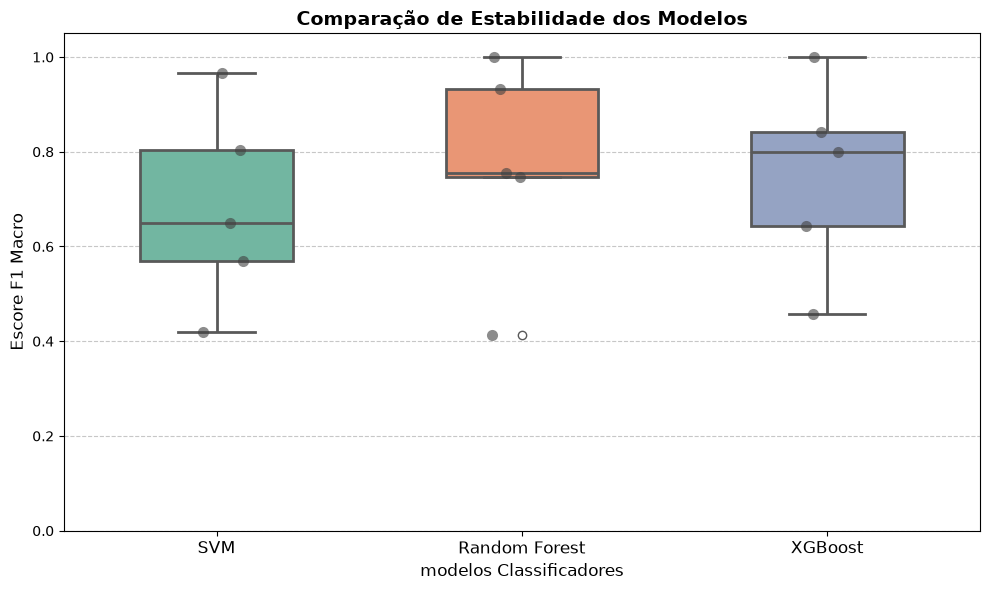

In [20]:

nomes_modelos = list(resultados_f1.keys())
resultados_modelos = list(resultados_f1.values())

plt.figure(figsize=(10, 6))


sns.boxplot(data=resultados_modelos, palette="Set2", width=0.5, linewidth=2)
sns.stripplot(data=resultados_modelos, color='.25', size=8, alpha=0.6, jitter=True)

plt.xticks(ticks=range(len(nomes_modelos)), labels=nomes_modelos, fontsize=12)
plt.title('Comparação de Estabilidade dos Modelos', fontsize=14, fontweight='bold')
plt.ylabel('Escore F1 Macro', fontsize=12)
plt.xlabel('modelos Classificadores', fontsize=12)
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


O **SVM** apresentou o menor F1 Macro médio e variação considerável entre os folds.

O **Random Forest** apresentou o maior F1 Macro médio, **0.77**, mas também apresentou variação alta entre os diferentes folds.

O **XGBoost** ficou com F1 Macro médio de **0.73** e uma variação ligeiramente menor que a do Random Forest. Os resultados mostram que o desempenho dos três modelos varia de acordo com o fold temporal usado na validação.

### Matrizes de confusão

As matrizes de confusão mostram como os erros de classificação se distribuem entre as três atividades nos modelos.

#### SVM

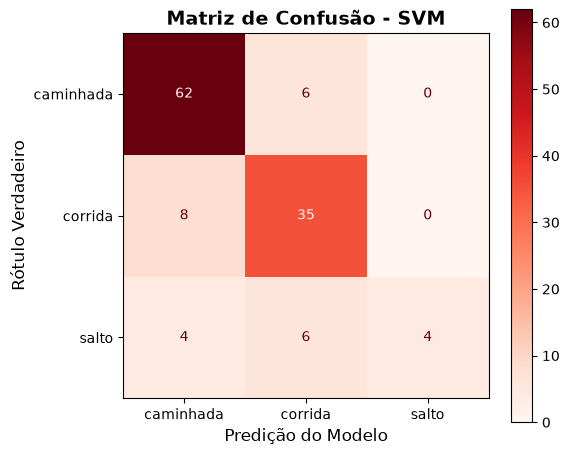

In [21]:
nomes_classes = encoder.classes_


matriz_confusao_svm = confusion_matrix(y, y_predito_svm)


plt.figure(figsize=(6, 5))
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_svm,
    display_labels=nomes_classes
)
disp_svm.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()

O SVM apresentou boa separação para caminhada e corrida, mas teve maior dificuldade na classe salto, acertando 4 das 14.

#### Random Forest

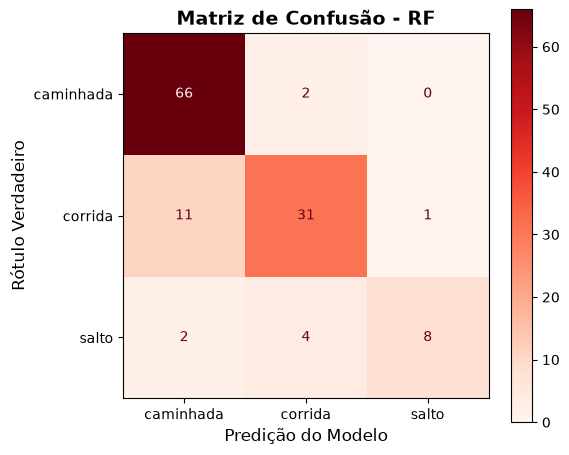

In [22]:
matriz_confusao_rf = confusion_matrix(y, y_predito_rf)


plt.figure(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_rf,
    display_labels=nomes_classes
)
disp_rf.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - RF', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()

O Random Forest apresentou poucos erros em caminhada e classificou corretamente 8 das 14 janelas de salto. A maior concentração de erros ocorreu na separação entre corrida e as outras atividades.

#### XGBoost

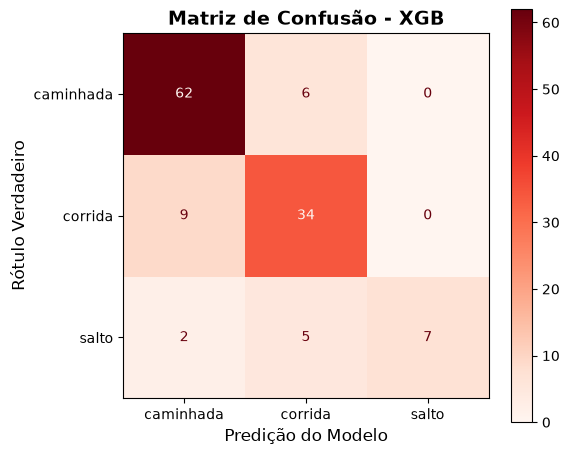

In [23]:
matriz_confusao_xgb = confusion_matrix(y, y_predito_xgb)


plt.figure(figsize=(6, 5))
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusao_xgb,
    display_labels=nomes_classes
)
disp_xgb.plot(cmap=plt.cm.Reds, values_format='d', ax=plt.gca())

plt.title('Matriz de Confusão - XGB', fontsize=14, fontweight='bold')
plt.xlabel('Predição do Modelo', fontsize=12)
plt.ylabel('Rótulo Verdadeiro', fontsize=12)
plt.grid(False)

plt.tight_layout()
plt.show()

O XGBoost apresentou um desempenho bom, ficando como intermediário entre SVM e Random Forest em métrica. Os erros também se concentraram em todas as classe. Porém, proporcionalmente, a classe com mais erros é também, salto, onde errou metade

### Resumo final

| Modelo | F1 Macro médio | Desvio padrão |
|---|---:|---:|
| SVM | 0,68 | 0,189 |
| **Random Forest** | **0,77** | 0,204 |
| XGBoost | 0,73 | 0,183 |

Pipeline final: **filtragem Butterworth → janelamento com 75% de overlap → extração de 15 features → validação cruzada em 5 folds por blocos temporais com remoção de janelas sobrepostas → comparação dos classificadores**.

## Conclusão

O pipeline conseguiu transformar o sinal bruto extraído do acelerômetro em um conjunto compacto de características e separar as três atividades com desempenho diferente entre os modelos.

A filtragem atenuou componentes fora da faixa definida antes do janelamento. Em seguida, cada janela de 128 × 3 foi reduzida a 15 características estatísticas e espectrais. O overlap de 75% aumentou a quantidade de janelas da classe salto, mantendo mais exemplos da classe minoritária para avaliação.

Na comparação final, o Random Forest apresentou o maior F1 Macro médio, seguido pelo XGBoost e pelo SVM. A variação entre os folds foi alta nos três modelos, O que mostra que o desempenho depende do trecho temporal utilizado na validação.

Para este conjunto de dados e este pipeline de processamento, o Random Forest apresentou o melhor desempenho médio na F1 Macro e, apesar de ter uma variação alta, a maioria dos seus valores estão acima de 0.74. 

A quantidade reduzida de janelas, principalmente da classe salto, ainda limita a estabilidade da avaliação e deve ser considerada.